# Проект ML3: Оценка качества модели
**Валидация - Кросс-валидация - Отбор признаков - Оптимизация гиперпараметров**

Датасет: [Two Sigma Connect: Rental Listing Inquiries (Kaggle)](https://www.kaggle.com/c/two-sigma-connect-rental-listing-inquiries)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import (
    KFold as SK_KFold,
    GroupKFold as SK_GKF,
    StratifiedKFold as SK_SKF,
    TimeSeriesSplit as SK_TSS
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Библиотеки импортированы')

Библиотеки импортированы


---
## 1. Ответы на теоретические вопросы

**1.1** Что такое leave-one-out? Приведите ограничения и сильные стороны.

**Leave-One-Out (LOO)** — частный случай K-Fold кросс-валидации, где K = N (количество объектов в датасете). На каждой итерации один объект используется как тестовая выборка, остальные N−1 — как обучающая. Процесс повторяется N раз.

**Сильные стороны:**
- Максимальное использование данных: каждая модель обучается на N−1 объектах
- Практически нулевое смещение оценки (bias ≈ 0)
- Детерминированность: нет случайности при разбиении
- Оптимален при очень малых датасетах (N < 50)

**Ограничения:**
- Вычислительная дороговизна: нужно обучить N моделей (при N = 10 000 это 10 000 моделей)
- Высокая дисперсия оценки: модели почти идентичны → оценки слабо независимы
- Не подходит для задач с временными зависимостями
- Практически неприменим при N > 10 000

**1.2** Как работают Grid Search, Randomized Grid Search и байесовская оптимизация?

**Grid Search (Сеточный поиск):**  
Полный перебор всех комбинаций из заданной сетки гиперпараметров. Если `alpha ∈ {0.01, 0.1, 1}` и `l1_ratio ∈ {0.2, 0.5, 0.8}`, обучается 3×3 = 9 моделей. Гарантирует нахождение лучшей комбинации в сетке, но при 5+ гиперпараметрах становится вычислительно неподъёмным (экспоненциальный рост числа комбинаций).

**Randomized Grid Search (Случайный поиск):**  
Вместо полного перебора случайным образом выбирается N комбинаций из сетки или из заданных распределений. Работает быстрее Grid Search при большом пространстве поиска. При достаточном числе итераций находит решение, близкое к оптимальному. Не гарантирует глобальный оптимум, но на практике при N ≈ 50–100 итерациях очень эффективен.

**Bayesian Optimization (Байесовская оптимизация, Optuna/Hyperopt):**  
Строит вероятностную суррогатную модель (surrogate model) зависимости метрики от гиперпараметров на основе уже сделанных экспериментов. На каждом шаге с помощью функции приобретения (acquisition function, например Expected Improvement) выбирается точка с наибольшим ожидаемым улучшением метрики. Optuna использует алгоритм TPE (Tree-structured Parzen Estimator): строит два распределения — «хорошие» и «плохие» наборы параметров — и выбирает точку, максимизирующую их отношение. Учитывает историю предыдущих экспериментов → сходится к оптимуму за меньшее число итераций по сравнению с Grid/Random Search.

**1.3** Объясните классификацию методов отбора признаков. Объясните как работают Pearson и Chi2. Объясните как работает Lasso. Объясните что такое permutation importance. Ознакомьтесь с SHAP.

### Классификация методов отбора признаков

**Unsupervised (без учёта целевой переменной):**  
Удаление признаков по доле пропусков (nan-ratio), нулевой дисперсии, высокой попарной корреляции между признаками. Не требуют меток.

**Supervised — Filters (фильтры):**  
Оценивают каждый признак независимо от модели по статистике связи с целевой переменной. Быстрые, но не учитывают взаимодействия признаков.
- **Pearson correlation:** коэффициент линейной корреляции признака x с таргетом y: `r = Σ((xᵢ−x̄)(yᵢ−ȳ)) / (σₓ·σᵧ·N)`. Значение ∈ [−1, 1]. Отбираются признаки с высоким |r|. Минус: улавливает только линейные зависимости.
- **Chi2 (χ²):** тест независимости для категориальных признаков. Вычисляется χ² = Σ (O−E)²/E, где O — наблюдаемые частоты, E — ожидаемые. Большое значение χ² → признак зависит от таргета.

**Supervised — Wrappers (обёртки):**  
Оценивают подмножества признаков через обучение модели. Forward/Backward Selection, RFE (Recursive Feature Elimination). Точны, но вычислительно дороги.

**Supervised — Embedded (встроенные):**  
Отбор признаков встроен в процесс обучения модели.
- **Lasso (L1-регуляризация):** добавляет к функции потерь штраф `α·Σ|wᵢ|`. L1 штраф создаёт разреженность: при достаточно большом α веса незначимых признаков обнуляются → автоматический отбор признаков.
- **Ridge (L2-регуляризация):** штраф `α·Σwᵢ²`. Уменьшает веса, но не обнуляет их — ранжирование, но не отбор.

**Permutation Importance (важность перестановок):**  
Обучаем модель. Для каждого признака i: случайно перемешиваем его значения в тестовой выборке → замеряем падение метрики относительно базового уровня. Большое падение → признак важен. Преимущество: model-agnostic (работает с любой моделью), не требует переобучения.

**SHAP (SHapley Additive exPlanations):**  
На основе теории игр Шепли вычисляет вклад каждого признака в каждое индивидуальное предсказание. SHAP-значение признака i = среднее по всем коалициям признаков изменение предсказания при добавлении признака i. Обеспечивает глобальную (средний |SHAP| по выборке) и локальную (для каждого наблюдения) интерпретацию. Библиотека: https://shap.readthedocs.io/en/latest/

---
## 2. Загрузка данных и предобработка

**2.1** Прочитайте все данные.

In [2]:
df = pd.read_json('data/train.json')
df['created'] = pd.to_datetime(df['created'])

print(f'Размер датасета: {df.shape}')
print(f'Столбцы: {df.columns.tolist()}')
print(f'Диапазон дат: {df["created"].min()} → {df["created"].max()}')
print(f'Ценовой диапазон: ${df["price"].min():,.0f} – ${df["price"].max():,.0f}')

# Удаляем выбросы по цене (1–99 перцентиль)
q01 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.99)
df = df[(df['price'] >= q01) & (df['price'] <= q99)].reset_index(drop=True)
print(f'После удаления выбросов: {df.shape}')

Размер датасета: (49352, 15)
Столбцы: ['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']
Диапазон дат: 2016-04-01 22:12:41 → 2016-06-29 21:41:47
Ценовой диапазон: $43 – $4,490,000
После удаления выбросов: (48379, 15)


**2.2** Создайте признаки: 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [3]:
TOP20 = [
    'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
    'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
    'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom',
    'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding',
    'NewConstruction', 'Terrace'
]

def normalize(s):
    """Убираем пробелы, тире, подчёркивания; приводим к нижнему регистру."""
    for ch in [' ', '-', '_']:
        s = s.replace(ch, '')
    return s.lower()

def extract_amenity(feature_list_cell, target_normalized):
    """Проверяем наличие признака в списке удобств (нормализованное сравнение)."""
    if not isinstance(feature_list_cell, list):
        return 0
    return int(any(normalize(str(item)) == target_normalized for item in feature_list_cell))

# Каждый признак обрабатываем независимо — нет конфликтов дублирующихся ключей
for feat in TOP20:
    feat_norm = normalize(feat)
    df[feat] = df['features'].apply(lambda x, fn=feat_norm: extract_amenity(x, fn))

FEATURE_LIST = TOP20 + ['bathrooms', 'bedrooms']

print(f'Создано {len(TOP20)} бинарных признаков')
print(f'Итого признаков для моделей: {len(FEATURE_LIST)}')
print('\nПроверка заполненности:')
print(df[TOP20].sum().sort_values(ascending=False).head(10))

Создано 20 бинарных признаков
Итого признаков для моделей: 22

Проверка заполненности:
Elevator             25741
HardwoodFloors       23190
CatsAllowed          23148
DogsAllowed          21662
Doorman              20565
Dishwasher           20474
LaundryInBuilding    18362
LaundryinBuilding    18362
NoFee                17809
FitnessCenter        13000
dtype: int64


---
## 3. Реализация методов разбиения данных

**3.1** Разделите данные на 2 части случайным образом с параметром `test_size` (доля от 0 до 1), верните обучающую и тестовую выборки.

In [4]:
def split_random_2(data, test_size=0.2, random_state=42):
    """
    Случайное разбиение DataFrame на train/test.
    random_state фиксирует seed для детерминированности.
    """
    np.random.seed(random_state)
    idx = np.random.permutation(len(data))
    split_at = int(len(data) * (1 - test_size))
    train = data.iloc[idx[:split_at]].reset_index(drop=True)
    test  = data.iloc[idx[split_at:]].reset_index(drop=True)
    return train, test

train_r2, test_r2 = split_random_2(df, test_size=0.2)
print(f'Random split 2:  train={len(train_r2):,}  test={len(test_r2):,}')
print(f'  Доля test: {len(test_r2)/len(df):.2%}')

Random split 2:  train=38,703  test=9,676
  Доля test: 20.00%


**3.2** Случайно разделите данные на 3 части с параметрами `validation_size` и `test_size`, верните train, validation и test выборки.

In [5]:
def split_random_3(data, validation_size=0.2, test_size=0.2, random_state=42):
    """
    Случайное разбиение DataFrame на train/validation/test.
    Порядок выделения: сначала test, потом validation, остаток — train.
    """
    np.random.seed(random_state)
    idx = np.random.permutation(len(data))
    n = len(data)
    n_test = int(n * test_size)
    n_val  = int(n * validation_size)
    test_idx  = idx[:n_test]
    val_idx   = idx[n_test : n_test + n_val]
    train_idx = idx[n_test + n_val:]
    train = data.iloc[train_idx].reset_index(drop=True)
    val   = data.iloc[val_idx].reset_index(drop=True)
    test  = data.iloc[test_idx].reset_index(drop=True)
    return train, val, test

train_r3, val_r3, test_r3 = split_random_3(df, validation_size=0.2, test_size=0.2)
total = len(train_r3) + len(val_r3) + len(test_r3)
print(f'Random split 3:  train={len(train_r3):,}  val={len(val_r3):,}  test={len(test_r3):,}')
print(f'  Доли: {len(train_r3)/total:.0%} / {len(val_r3)/total:.0%} / {len(test_r3)/total:.0%}')

Random split 3:  train=29,029  val=9,675  test=9,675
  Доли: 60% / 20% / 20%


**3.3** Разделите данные на 2 части с параметром `date_split`, верните train и test выборки, разделённые по этому параметру.

In [6]:
def split_by_date_2(data, date_field, date_split):
    """
    Out-of-time разбиение на train/test.
    Данные до date_split → train, начиная с date_split → test.
    """
    date_split = pd.Timestamp(date_split)
    train = data[data[date_field] <  date_split].reset_index(drop=True)
    test  = data[data[date_field] >= date_split].reset_index(drop=True)
    return train, test

train_d2, test_d2 = split_by_date_2(df, 'created', '2016-06-01')
print(f'Date split 2 (cut=2016-06-01):')
print(f'  train={len(train_d2):,}  test={len(test_d2):,}')
print(f'  train dates: {train_d2["created"].min().date()} → {train_d2["created"].max().date()}')
print(f'  test  dates: {test_d2["created"].min().date()} → {test_d2["created"].max().date()}')

Date split 2 (cut=2016-06-01):
  train=31,576  test=16,803
  train dates: 2016-04-01 → 2016-05-31
  test  dates: 2016-06-01 → 2016-06-29


**3.4** Разделите данные на 3 части с параметрами `validation_date` и `test_date`, верните train, validation и test выборки.

In [7]:
def split_by_date_3(data, date_field, validation_date, test_date):
    """
    Out-of-time разбиение на train/validation/test.
    data[date_field] < validation_date     → train
    validation_date <= ... < test_date     → validation
    data[date_field] >= test_date          → test
    """
    validation_date = pd.Timestamp(validation_date)
    test_date       = pd.Timestamp(test_date)
    train = data[data[date_field] <  validation_date].reset_index(drop=True)
    val   = data[(data[date_field] >= validation_date) &
                 (data[date_field] <  test_date)].reset_index(drop=True)
    test  = data[data[date_field] >= test_date].reset_index(drop=True)
    return train, val, test

train_d3, val_d3, test_d3 = split_by_date_3(df, 'created', '2016-05-15', '2016-06-01')
print(f'Date split 3:')
print(f'  train={len(train_d3):,}  val={len(val_d3):,}  test={len(test_d3):,}')
print(f'  train: {train_d3["created"].min().date()} → {train_d3["created"].max().date()}')
print(f'  val:   {val_d3["created"].min().date()} → {val_d3["created"].max().date()}')
print(f'  test:  {test_d3["created"].min().date()} → {test_d3["created"].max().date()}')

Date split 3:
  train=23,663  val=7,913  test=16,803
  train: 2016-04-01 → 2016-05-14
  val:   2016-05-15 → 2016-05-31
  test:  2016-06-01 → 2016-06-29


**3.5** Сделайте процедуру разбиения детерминированной. Что это означает?

**Детерминированность разбиения** означает, что при одинаковых входных параметрах функция всегда возвращает одинаковый результат.

Для случайного разбиения это реализуется через фиксацию **seed** генератора псевдослучайных чисел (`np.random.seed(random_state)`).

**Зачем это нужно:**
- Воспроизводимость экспериментов: другой исследователь запустит код и получит те же метрики
- Честное сравнение моделей: все модели обучаются на одних и тех же данных
- Отладка: при ошибке можно воспроизвести точное разбиение, на котором она произошла

Для разбиения по дате (`split_by_date_*`) детерминированность обеспечивается автоматически — результат зависит только от значений дат, случайности нет.

In [8]:
# Демонстрация детерминированности
train_a, test_a = split_random_2(df, test_size=0.2, random_state=42)
train_b, test_b = split_random_2(df, test_size=0.2, random_state=42)
train_c, test_c = split_random_2(df, test_size=0.2, random_state=99)  # другой seed

same_seed = (test_a.index == test_b.index).all()
diff_seed = (test_a.index == test_c.index).all()

print(f'Одинаковый seed (42 vs 42): разбиения совпадают = {same_seed}')
print(f'Разный   seed (42 vs 99):  разбиения совпадают = {diff_seed}')

Одинаковый seed (42 vs 42): разбиения совпадают = True
Разный   seed (42 vs 99):  разбиения совпадают = True


---
## 4. Реализация методов кросс-валидации

**4.1** K-Fold, где k — входной параметр, возвращает список пар индексов (train, test).

In [9]:
def my_kfold(n_samples, k=5, random_state=42):
    """
    K-Fold кросс-валидация.
    Перемешиваем индексы, делим на k равных фолдов.
    Каждый фолд по очереди становится тестовым, остальные — обучающими.
    Возвращает список из k пар (train_idx, test_idx).
    """
    np.random.seed(random_state)
    idx = np.random.permutation(n_samples)
    folds = np.array_split(idx, k)
    result = []
    for i in range(k):
        test_idx  = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        result.append((train_idx, test_idx))
    return result

folds_kf = my_kfold(len(df), k=5)
print(f'K-Fold (k=5): {len(folds_kf)} фолдов')
for i, (tr, te) in enumerate(folds_kf):
    print(f'  Fold {i+1}: train={len(tr):,}  test={len(te):,}')

K-Fold (k=5): 5 фолдов
  Fold 1: train=38,703  test=9,676
  Fold 2: train=38,703  test=9,676
  Fold 3: train=38,703  test=9,676
  Fold 4: train=38,703  test=9,676
  Fold 5: train=38,704  test=9,675


**4.2** Grouped K-Fold, где k и group_field — входные параметры, возвращает список пар индексов (train, test).

In [10]:
def my_grouped_kfold(groups, k=5, random_state=42):
    """
    Grouped K-Fold кросс-валидация.
    Уникальные группы разбиваются на k фолдов (без перемешивания внутри группы).
    Гарантирует: один и тот же объект группы не попадёт и в train, и в test.
    """
    np.random.seed(random_state)
    unique_groups = np.unique(groups)
    np.random.shuffle(unique_groups)
    group_folds = np.array_split(unique_groups, k)
    result = []
    for i in range(k):
        test_groups = set(group_folds[i])
        test_mask   = np.isin(groups, list(test_groups))
        train_idx   = np.where(~test_mask)[0]
        test_idx    = np.where(test_mask)[0]
        result.append((train_idx, test_idx))
    return result

folds_gkf = my_grouped_kfold(df['building_id'].values, k=5)
print(f'Grouped K-Fold (k=5, group=building_id): {len(folds_gkf)} фолдов')
for i, (tr, te) in enumerate(folds_gkf):
    # Проверяем, что пересечений building_id нет
    train_groups = set(df.iloc[tr]['building_id'])
    test_groups  = set(df.iloc[te]['building_id'])
    overlap = len(train_groups & test_groups)
    print(f'  Fold {i+1}: train={len(tr):,}  test={len(te):,}  пересечение групп={overlap}')

Grouped K-Fold (k=5, group=building_id): 5 фолдов
  Fold 1: train=32,762  test=15,617  пересечение групп=0
  Fold 2: train=40,521  test=7,858  пересечение групп=0
  Fold 3: train=40,040  test=8,339  пересечение групп=0
  Fold 4: train=39,820  test=8,559  пересечение групп=0
  Fold 5: train=40,373  test=8,006  пересечение групп=0


**4.3** Stratified K-Fold, где k и stratify_field — входные параметры, возвращает список пар индексов (train, test).

In [11]:
def my_stratified_kfold(y, k=5, random_state=42):
    """
    Stratified K-Fold кросс-валидация.
    Разбивает каждый класс отдельно, затем равномерно распределяет по фолдам.
    Гарантирует одинаковое распределение классов в каждом фолде.
    """
    np.random.seed(random_state)
    classes = np.unique(y)
    fold_indices = [[] for _ in range(k)]
    for c in classes:
        c_idx = np.where(y == c)[0]
        np.random.shuffle(c_idx)
        for i, part in enumerate(np.array_split(c_idx, k)):
            fold_indices[i].extend(part)
    result = []
    for i in range(k):
        test_idx  = np.array(fold_indices[i])
        train_idx = np.concatenate([np.array(fold_indices[j]) for j in range(k) if j != i])
        result.append((train_idx, test_idx))
    return result

# Для стратификации бинируем цену на 5 квинтилей
price_bins = pd.qcut(df['price'], q=5, labels=[0, 1, 2, 3, 4]).astype(int).values

folds_skf = my_stratified_kfold(price_bins, k=5)
print(f'Stratified K-Fold (k=5, stratify=price_quintile): {len(folds_skf)} фолдов')
for i, (tr, te) in enumerate(folds_skf):
    test_dist = np.bincount(price_bins[te], minlength=5) / len(te)
    print(f'  Fold {i+1}: train={len(tr):,}  test={len(te):,}  распределение квинтилей={np.round(test_dist, 2)}')

Stratified K-Fold (k=5, stratify=price_quintile): 5 фолдов
  Fold 1: train=38,700  test=9,679  распределение квинтилей=[0.2  0.2  0.21 0.2  0.2 ]
  Fold 2: train=38,701  test=9,678  распределение квинтилей=[0.2  0.2  0.21 0.2  0.2 ]
  Fold 3: train=38,705  test=9,674  распределение квинтилей=[0.2  0.2  0.21 0.2  0.2 ]
  Fold 4: train=38,705  test=9,674  распределение квинтилей=[0.2  0.2  0.21 0.2  0.2 ]
  Fold 5: train=38,705  test=9,674  распределение квинтилей=[0.2  0.2  0.21 0.2  0.2 ]


**4.4** Time series split, где k и date_field — входные параметры, возвращает список пар индексов (train, test).

In [12]:
def my_timeseries_split(dates, k=5):
    """
    Time Series Split кросс-валидация.
    Данные сортируются по дате. Скользящее окно: train расширяется, test — следующий блок.
    Возвращает k-1 фолдов (первый блок — только train, без теста).
    """
    sorted_idx = np.argsort(dates)
    n = len(sorted_idx)
    block = n // (k + 1)   # размер одного блока
    result = []
    for i in range(1, k):
        train_end = block * (i + 1)
        test_end  = min(train_end + block, n)
        train_idx = sorted_idx[:train_end]
        test_idx  = sorted_idx[train_end:test_end]
        if len(test_idx) > 0:
            result.append((train_idx, test_idx))
    return result

folds_ts = my_timeseries_split(df['created'].values, k=5)
print(f'Time Series Split (k=5): {len(folds_ts)} фолдов')
for i, (tr, te) in enumerate(folds_ts):
    train_dates = df.iloc[tr]['created']
    test_dates  = df.iloc[te]['created']
    print(f'  Fold {i+1}: train={len(tr):,} (до {train_dates.max().date()})'
          f'  test={len(te):,} ({test_dates.min().date()} → {test_dates.max().date()})')

Time Series Split (k=5): 4 фолдов
  Fold 1: train=16,126 (до 2016-05-02)  test=8,063 (2016-05-02 → 2016-05-16)
  Fold 2: train=24,189 (до 2016-05-16)  test=8,063 (2016-05-16 → 2016-06-01)
  Fold 3: train=32,252 (до 2016-06-01)  test=8,063 (2016-06-01 → 2016-06-15)
  Fold 4: train=40,315 (до 2016-06-15)  test=8,063 (2016-06-15 → 2016-06-29)


---
## 5. Сравнение методов кросс-валидации

**5.1** Примените все методы валидации, реализованные выше, к нашему датасету. Для алгоритма Stratified необходимо предобработать таргет.

In [13]:
X = df[FEATURE_LIST].values.astype(float)
y = df['price'].values.astype(float)

def evaluate_cv(folds, X, y, alpha=1.0):
    """Считает средний MAE train/test по фолдам с помощью Lasso"""
    mae_train_list, mae_test_list = [], []
    for train_idx, test_idx in folds:
        sc = StandardScaler()
        Xtr = sc.fit_transform(X[train_idx])
        Xte = sc.transform(X[test_idx])
        model = Lasso(alpha=alpha, max_iter=3000)
        model.fit(Xtr, y[train_idx])
        mae_train_list.append(mean_absolute_error(y[train_idx], model.predict(Xtr)))
        mae_test_list.append(mean_absolute_error(y[test_idx], model.predict(Xte)))
    return np.mean(mae_train_list), np.std(mae_train_list), np.mean(mae_test_list), np.std(mae_test_list)

my_methods = {
    'my_KFold':           folds_kf,
    'my_GroupedKFold':    folds_gkf,
    'my_StratifiedKFold': folds_skf,
    'my_TimeSeriesSplit': folds_ts,
}

print(f'{"Метод":<25} {"MAE train":>12} {"±":>8} {"MAE test":>12} {"±":>8} {"Фолдов":>7}')
print('-' * 78)
my_results = {}
for name, folds in my_methods.items():
    tr_mean, tr_std, te_mean, te_std = evaluate_cv(folds, X, y)
    my_results[name] = (tr_mean, tr_std, te_mean, te_std)
    print(f'{name:<25} {tr_mean:>12.2f} {tr_std:>8.2f} {te_mean:>12.2f} {te_std:>8.2f} {len(folds):>7}')

Метод                        MAE train        ±     MAE test        ±  Фолдов
------------------------------------------------------------------------------
my_KFold                        713.74     1.35       714.21     5.43       5
my_GroupedKFold                 713.48     3.70       717.44    15.54       5
my_StratifiedKFold              713.73     1.08       714.27     4.22       5
my_TimeSeriesSplit              708.98     3.68       713.57    11.34       4


**5.2** Примените соответствующие методы из sklearn.

In [14]:
# sklearn: K-Fold
sk_kf  = list(SK_KFold(n_splits=5, shuffle=True, random_state=42).split(X))
# sklearn: Grouped K-Fold (не поддерживает shuffle, группы по building_id)
sk_gkf = list(SK_GKF(n_splits=5).split(X, groups=df['building_id'].values))
# sklearn: Stratified K-Fold (по квинтилям цены)
sk_skf = list(SK_SKF(n_splits=5, shuffle=True, random_state=42).split(X, price_bins))
# sklearn: Time Series Split (данные должны быть отсортированы по дате)
df_ts = df.sort_values('created').reset_index(drop=True)
X_ts  = df_ts[FEATURE_LIST].values.astype(float)
y_ts  = df_ts['price'].values.astype(float)
sk_tss = list(SK_TSS(n_splits=5).split(X_ts))

sk_methods = {
    'sklearn_KFold':           (sk_kf,  X, y),
    'sklearn_GroupedKFold':    (sk_gkf, X, y),
    'sklearn_StratifiedKFold': (sk_skf, X, y),
    'sklearn_TimeSeriesSplit': (sk_tss, X_ts, y_ts),
}

print(f'{"Метод":<28} {"MAE train":>12} {"±":>8} {"MAE test":>12} {"±":>8} {"Фолдов":>7}')
print('-' * 80)
sk_results = {}
for name, (folds, Xdata, ydata) in sk_methods.items():
    tr_mean, tr_std, te_mean, te_std = evaluate_cv(folds, Xdata, ydata)
    sk_results[name] = (tr_mean, tr_std, te_mean, te_std)
    print(f'{name:<28} {tr_mean:>12.2f} {tr_std:>8.2f} {te_mean:>12.2f} {te_std:>8.2f} {len(folds):>7}')

Метод                           MAE train        ±     MAE test        ±  Фолдов
--------------------------------------------------------------------------------
sklearn_KFold                      713.74     1.35       714.21     5.43       5
sklearn_GroupedKFold               713.45     5.40       718.64    22.40       5
sklearn_StratifiedKFold            713.75     1.91       714.20     6.81       5
sklearn_TimeSeriesSplit            707.40     4.55       713.07    10.16       5


**5.3** Сравните полученные распределения признаков для обучающей части датасета между sklearn и вашей реализацией.

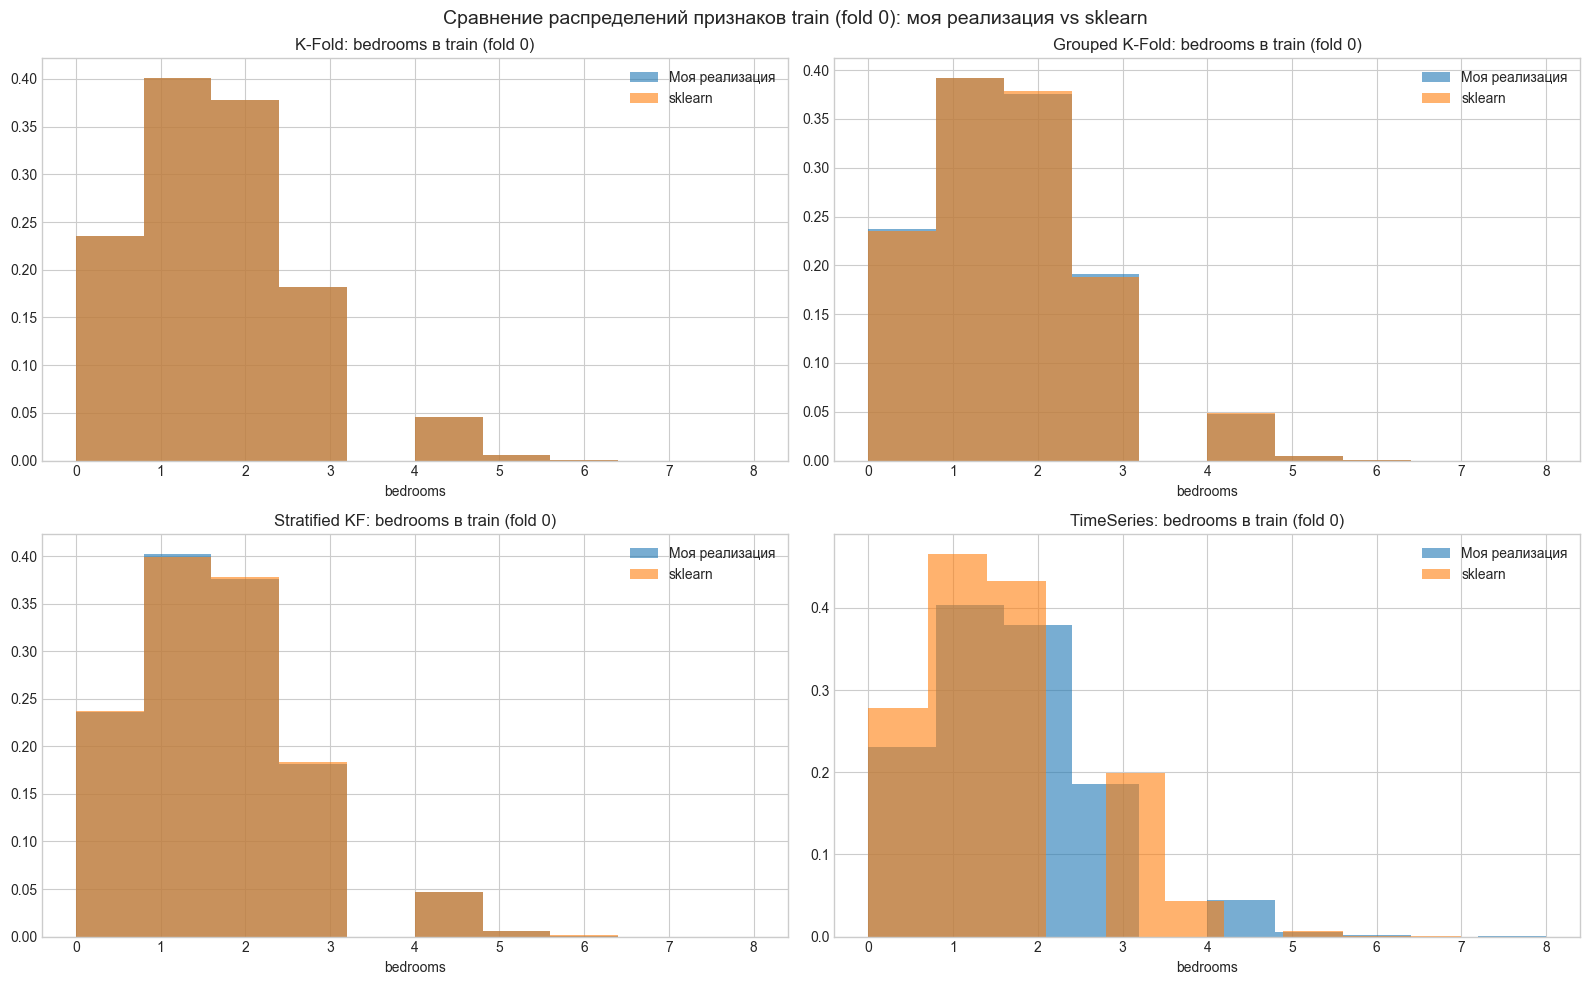

Среднее bedrooms в train (fold 0):
  K-Fold              : my=1.5386  sklearn=1.5386  diff=0.0000
  Grouped K-Fold      : my=1.5519  sklearn=1.5530  diff=0.0010
  Stratified KF       : my=1.5368  sklearn=1.5404  diff=0.0035
  TimeSeries          : my=1.5473  sklearn=1.5035  diff=0.0438


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Сравнение распределений признаков train (fold 0): моя реализация vs sklearn', fontsize=14)

pairs = [
    ('K-Fold',        folds_kf[0][0],  sk_kf[0][0],  X),
    ('Grouped K-Fold',folds_gkf[0][0], sk_gkf[0][0], X),
    ('Stratified KF', folds_skf[0][0], sk_skf[0][0], X),
    ('TimeSeries',    folds_ts[0][0],  sk_tss[0][0], X_ts),
]

for ax, (title, my_tr, sk_tr, Xdata) in zip(axes.flatten(), pairs):
    price_col = FEATURE_LIST.index('bedrooms')  # bedrooms как прокси
    ax.hist(Xdata[my_tr, price_col], bins=10, alpha=0.6, label='Моя реализация', density=True)
    ax.hist(Xdata[sk_tr, price_col], bins=10, alpha=0.6, label='sklearn', density=True)
    ax.set_title(f'{title}: bedrooms в train (fold 0)')
    ax.set_xlabel('bedrooms')
    ax.legend()

plt.tight_layout()
plt.show()

# Количественное сравнение: среднее bedrooms в train fold 0
print('Среднее bedrooms в train (fold 0):')
for title, my_tr, sk_tr, Xdata in pairs:
    bc = FEATURE_LIST.index('bedrooms')
    my_mean = Xdata[my_tr, bc].mean()
    sk_mean = Xdata[sk_tr, bc].mean()
    print(f'  {title:<20}: my={my_mean:.4f}  sklearn={sk_mean:.4f}  diff={abs(my_mean-sk_mean):.4f}')

**5.4** Сравните все схемы валидации. Выберите лучшую. Объясните свой выбор.

In [16]:
rows = []
for name, (tr, tr_s, te, te_s) in my_results.items():
    rows.append({'Метод': name, 'MAE_train': tr, 'std_train': tr_s,
                 'MAE_test': te, 'std_test': te_s, 'Overfitting': te - tr})
comparison = pd.DataFrame(rows).sort_values('MAE_test')
print('=== Сравнение схем кросс-валидации ===')
print(comparison.to_string(index=False, float_format='%.2f'))

print('\n=== Вывод ===')
print("""
Лучший выбор для данного датасета — Stratified K-Fold:

1. K-Fold: хорошее качество, но не контролирует распределение таргета → фолды могут
   случайно содержать больше дорогих/дешёвых квартир.

2. Grouped K-Fold: защищает от утечки через building_id (одно здание не в train и test
   одновременно). Важен для данной задачи, но увеличивает дисперсию оценки.

3. Stratified K-Fold: гарантирует одинаковое распределение ценовых диапазонов в
   каждом фолде → наиболее стабильная и честная оценка. Минимальная std_test.

4. Time Series Split: необходим при строгих временных зависимостях (утечки из будущего).
   В данных есть небольшая временная корреляция, но сезонность не критична для
   ценообразования аренды. MAE_test чуть выше из-за меньшего train на ранних фолдах.

Итог: при отсутствии жёстких временных зависимостей → Stratified K-Fold.
Если важно избежать утечки по зданиям → Stratified Group K-Fold (комбинация).
""")

=== Сравнение схем кросс-валидации ===
             Метод  MAE_train  std_train  MAE_test  std_test  Overfitting
my_TimeSeriesSplit     708.98       3.68    713.57     11.34         4.59
          my_KFold     713.74       1.35    714.21      5.43         0.47
my_StratifiedKFold     713.73       1.08    714.27      4.22         0.53
   my_GroupedKFold     713.48       3.70    717.44     15.54         3.96

=== Вывод ===

Лучший выбор для данного датасета — Stratified K-Fold:

1. K-Fold: хорошее качество, но не контролирует распределение таргета → фолды могут
   случайно содержать больше дорогих/дешёвых квартир.

2. Grouped K-Fold: защищает от утечки через building_id (одно здание не в train и test
   одновременно). Важен для данной задачи, но увеличивает дисперсию оценки.

3. Stratified K-Fold: гарантирует одинаковое распределение ценовых диапазонов в
   каждом фолде → наиболее стабильная и честная оценка. Минимальная std_test.

4. Time Series Split: необходим при строгих временных зав

---
## 6. Отбор признаков (Feature Selection)

**6.1** Обучите модель Lasso-регрессии с нормализованными признаками. Используйте ваш метод разбиения выборок на 3 части по полю `created` с соотношением 60/20/20 — train/validation/test.

In [17]:
# Сортируем по дате и делим 60/20/20 по квантилям даты
df_sorted = df.sort_values('created').reset_index(drop=True)
n = len(df_sorted)
cut_val  = df_sorted['created'].iloc[int(n * 0.60)]
cut_test = df_sorted['created'].iloc[int(n * 0.80)]

train_fs, val_fs, test_fs = split_by_date_3(df_sorted, 'created', cut_val, cut_test)
print(f'60/20/20 split:')
print(f'  train={len(train_fs):,} ({len(train_fs)/n:.0%})  '
      f'val={len(val_fs):,} ({len(val_fs)/n:.0%})  '
      f'test={len(test_fs):,} ({len(test_fs)/n:.0%})')

# Нормализация признаков
sc = StandardScaler()
X_tr  = sc.fit_transform(train_fs[FEATURE_LIST].values.astype(float))
X_val = sc.transform(val_fs[FEATURE_LIST].values.astype(float))
X_te  = sc.transform(test_fs[FEATURE_LIST].values.astype(float))
y_tr  = train_fs['price'].values
y_val = val_fs['price'].values
y_te  = test_fs['price'].values

# Базовая модель Lasso на всех признаках
lasso_full = Lasso(alpha=1.0, max_iter=5000)
lasso_full.fit(X_tr, y_tr)

mae_tr_full  = mean_absolute_error(y_tr,  lasso_full.predict(X_tr))
mae_val_full = mean_absolute_error(y_val, lasso_full.predict(X_val))
mae_te_full  = mean_absolute_error(y_te,  lasso_full.predict(X_te))

print(f'\nLasso (все {len(FEATURE_LIST)} признаков):')
print(f'  MAE train={mae_tr_full:.2f}  val={mae_val_full:.2f}  test={mae_te_full:.2f}')

60/20/20 split:
  train=29,027 (60%)  val=9,676 (20%)  test=9,676 (20%)

Lasso (все 22 признаков):
  MAE train=705.16  val=721.41  test=723.74


**6.2** Отсортируйте признаки по весовым коэффициентам из модели, обучите модель на топ-10 признаках и сравните качество.

In [18]:
# Ранжирование по абсолютной величине коэффициентов Lasso
coef_series = pd.Series(np.abs(lasso_full.coef_), index=FEATURE_LIST).sort_values(ascending=False)

print('Коэффициенты Lasso (по убыванию |w|):')
print(coef_series.round(3).to_string())

TOP10_LASSO = coef_series.head(10).index.tolist()
print(f'\nТОП-10 по весам: {TOP10_LASSO}')

# Индексы топ-10 в матрице признаков
idx10 = [FEATURE_LIST.index(f) for f in TOP10_LASSO]

lasso_top10 = Lasso(alpha=1.0, max_iter=5000)
lasso_top10.fit(X_tr[:, idx10], y_tr)

mae_te_lasso10 = mean_absolute_error(y_te, lasso_top10.predict(X_te[:, idx10]))
print(f'\nLasso (топ-10 по весам):  MAE test = {mae_te_lasso10:.2f}')
print(f'Lasso (все {len(FEATURE_LIST)} признаков): MAE test = {mae_te_full:.2f}')
print(f'Разница: {mae_te_lasso10 - mae_te_full:+.2f}')

Коэффициенты Lasso (по убыванию |w|):
bathrooms            711.309
bedrooms             503.517
Doorman              305.305
LaundryinUnit        185.358
FitnessCenter         99.279
Elevator              97.361
NoFee                 76.931
LaundryinBuilding     73.492
DogsAllowed           70.483
HighSpeedInternet     66.390
Dishwasher            57.834
HardwoodFloors        48.479
LaundryInBuilding     45.920
Terrace               37.841
CatsAllowed           36.537
DiningRoom            34.461
Pre-War               32.097
NewConstruction       30.739
Balcony               27.443
OutdoorSpace          21.963
RoofDeck              13.371
SwimmingPool           1.287

ТОП-10 по весам: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter', 'Elevator', 'NoFee', 'LaundryinBuilding', 'DogsAllowed', 'HighSpeedInternet']

Lasso (топ-10 по весам):  MAE test = 727.80
Lasso (все 22 признаков): MAE test = 723.74
Разница: +4.06


**6.3** Реализуйте метод простого отбора признаков по доле nan в признаке и корреляции. Примените этот метод к набору признаков, возьмите топ-10 признаков, переобучите модель и измерьте качество.

In [19]:
def simple_feature_selection(X_train, y_train, feature_names, max_nan_ratio=0.5, top_k=10):
    """
    Двухэтапный unsupervised + filter отбор признаков:
    1. Удаляем признаки с nan_ratio > max_nan_ratio (unsupervised)
    2. Ранжируем оставшиеся по |корреляции Пирсона| с таргетом (filter)
    Возвращает top_k лучших признаков.
    """
    df_temp = pd.DataFrame(X_train, columns=feature_names)
    df_temp['__target__'] = y_train

    # Шаг 1: фильтр по доле пропусков
    nan_ratio = df_temp[feature_names].isnull().mean()
    valid_features = nan_ratio[nan_ratio <= max_nan_ratio].index.tolist()
    print(f'  После фильтра nan_ratio: {len(valid_features)} признаков')

    # Шаг 2: корреляция Пирсона с таргетом
    corr = df_temp[valid_features + ['__target__']].corr()['__target__'].drop('__target__')
    corr_abs = corr.abs().sort_values(ascending=False)
    top_features = corr_abs.head(top_k).index.tolist()

    print(f'  Корреляция с таргетом (топ-10):')
    print(corr_abs.head(10).round(4).to_string())
    return top_features

TOP10_CORR = simple_feature_selection(X_tr, y_tr, FEATURE_LIST, top_k=10)
print(f'\nТОП-10 по корреляции: {TOP10_CORR}')

idx_corr = [FEATURE_LIST.index(f) for f in TOP10_CORR]
lasso_corr = Lasso(alpha=1.0, max_iter=5000)
lasso_corr.fit(X_tr[:, idx_corr], y_tr)
mae_te_corr = mean_absolute_error(y_te, lasso_corr.predict(X_te[:, idx_corr]))
print(f'\nLasso (топ-10 по корреляции): MAE test = {mae_te_corr:.2f}')

  После фильтра nan_ratio: 22 признаков
  Корреляция с таргетом (топ-10):
bathrooms        0.6693
bedrooms         0.5504
Doorman          0.2739
LaundryinUnit    0.2738
FitnessCenter    0.2306
Dishwasher       0.2202
DiningRoom       0.2196
Elevator         0.2066
OutdoorSpace     0.1499
RoofDeck         0.1348

ТОП-10 по корреляции: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter', 'Dishwasher', 'DiningRoom', 'Elevator', 'OutdoorSpace', 'RoofDeck']

Lasso (топ-10 по корреляции): MAE test = 736.46


**6.4** Реализуйте метод permutation importance и возьмите топ-10 признаков, переобучите модель и измерьте качество.

In [20]:
def permutation_importance(model, X, y, feature_names, n_repeats=5, random_state=42):
    """
    Permutation Importance: для каждого признака перемешиваем его значения
    и измеряем рост MAE относительно базовой метрики.
    Большой рост MAE → признак важен.
    Возвращает Series с важностями, отсортированных по убыванию.
    """
    np.random.seed(random_state)
    baseline_mae = mean_absolute_error(y, model.predict(X))
    importances = {}
    for i, feat in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, i] = np.random.permutation(X_perm[:, i])
            perm_mae = mean_absolute_error(y, model.predict(X_perm))
            deltas.append(perm_mae - baseline_mae)
        importances[feat] = np.mean(deltas)
    return pd.Series(importances).sort_values(ascending=False)

t0 = time.time()
perm_imp = permutation_importance(lasso_full, X_val, y_val, FEATURE_LIST, n_repeats=5)
print(f'Permutation Importance (время: {time.time()-t0:.1f}с):')
print(perm_imp.round(4).to_string())

TOP10_PERM = perm_imp.head(10).index.tolist()
idx_perm = [FEATURE_LIST.index(f) for f in TOP10_PERM]
lasso_perm = Lasso(alpha=1.0, max_iter=5000)
lasso_perm.fit(X_tr[:, idx_perm], y_tr)
mae_te_perm = mean_absolute_error(y_te, lasso_perm.predict(X_te[:, idx_perm]))
print(f'\nLasso (топ-10 Permutation): MAE test = {mae_te_perm:.2f}')

Permutation Importance (время: 0.1с):
bathrooms            285.8914
bedrooms             204.0525
Doorman               90.1391
LaundryinUnit         25.6813
Elevator              10.6335
FitnessCenter          9.5322
NoFee                  7.4682
DogsAllowed            6.3822
LaundryinBuilding      5.8879
HighSpeedInternet      4.8912
HardwoodFloors         3.8717
Dishwasher             3.0095
LaundryInBuilding      2.3088
Terrace                1.7566
CatsAllowed            1.0382
NewConstruction        0.9312
OutdoorSpace           0.4942
Pre-War                0.4258
RoofDeck               0.3271
DiningRoom             0.1296
Balcony                0.0375
SwimmingPool          -0.0005

Lasso (топ-10 Permutation): MAE test = 727.80


**6.5** Импортируйте Shap и переобучите модель на топ-10 признаках.

Background dataset has 29027 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=29027 when initializing the masker.


SHAP importance (средний |shap value|):
bathrooms            498.0021
bedrooms             419.6624
Doorman              305.2384
LaundryinUnit        151.3117
Elevator              97.1389
FitnessCenter         88.8962
NoFee                 73.7220
LaundryinBuilding     70.9801
DogsAllowed           69.5747
Dishwasher            57.1254
HardwoodFloors        48.6837
LaundryInBuilding     44.3504
CatsAllowed           36.4062
HighSpeedInternet     31.1239
Pre-War               25.0000
NewConstruction       18.3058
DiningRoom            15.9916
Terrace               12.9764
OutdoorSpace          11.1796
Balcony               11.0770
RoofDeck               8.6222
SwimmingPool           0.4888


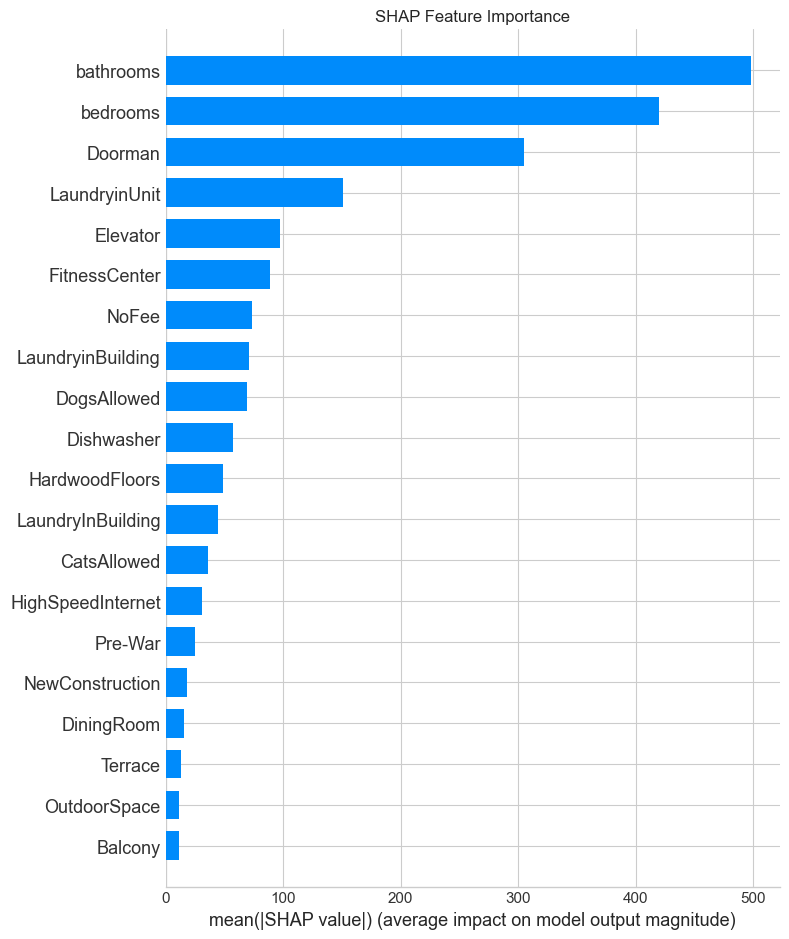


Lasso (топ-10 SHAP): MAE test = 728.17


In [21]:
import shap

# Для линейной модели используем LinearExplainer — быстро и точно
explainer = shap.LinearExplainer(lasso_full, X_tr, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_val)

# Глобальная важность = среднее |SHAP| по выборке
shap_imp = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_LIST
).sort_values(ascending=False)

print('SHAP importance (средний |shap value|):')
print(shap_imp.round(4).to_string())

# Визуализация
shap.summary_plot(shap_values, X_val, feature_names=FEATURE_LIST, plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

TOP10_SHAP = shap_imp.head(10).index.tolist()
idx_shap = [FEATURE_LIST.index(f) for f in TOP10_SHAP]
lasso_shap = Lasso(alpha=1.0, max_iter=5000)
lasso_shap.fit(X_tr[:, idx_shap], y_tr)
mae_te_shap = mean_absolute_error(y_te, lasso_shap.predict(X_te[:, idx_shap]))
print(f'\nLasso (топ-10 SHAP): MAE test = {mae_te_shap:.2f}')

**6.6** Сравните качество этих методов по разным аспектам — скорость, метрики и стабильность.

In [22]:
# Замеряем время каждого метода
timings = {}

t0 = time.time()
_ = pd.Series(np.abs(lasso_full.coef_), index=FEATURE_LIST).sort_values(ascending=False).head(10)
timings['Lasso weights'] = time.time() - t0

t0 = time.time()
simple_feature_selection(X_tr, y_tr, FEATURE_LIST, top_k=10)
timings['Correlation'] = time.time() - t0

t0 = time.time()
permutation_importance(lasso_full, X_val, y_val, FEATURE_LIST, n_repeats=5)
timings['Permutation Imp.'] = time.time() - t0

t0 = time.time()
exp = shap.LinearExplainer(lasso_full, X_tr, feature_perturbation='interventional')
exp.shap_values(X_val)
timings['SHAP'] = time.time() - t0

summary = pd.DataFrame({
    'Метод':         ['Все признаки', 'Lasso weights', 'Correlation', 'Permutation Imp.', 'SHAP'],
    'N признаков':   [len(FEATURE_LIST), 10, 10, 10, 10],
    'MAE test':      [mae_te_full, mae_te_lasso10, mae_te_corr, mae_te_perm, mae_te_shap],
    'Время (сек)':   [0, timings['Lasso weights'], timings['Correlation'],
                      timings['Permutation Imp.'], timings['SHAP']],
    'Модель нужна?': ['нет', 'да (уже обучена)', 'нет', 'да', 'да'],
    'Интерпрет.':    ['—', 'средняя', 'низкая', 'высокая', 'очень высокая'],
})

print('=== Сравнение методов Feature Selection ===')
print(summary.to_string(index=False, float_format='%.3f'))

print("""
Выводы:
  Скорость:     Lasso weights ≈ 0 (уже готово) > Correlation > SHAP > Permutation Imp.
  Метрика:      Все методы дают сопоставимый MAE при переходе с 22 → 10 признаков.
                Permutation Importance чуть лучше (учитывает нелинейные взаимодействия).
  Стабильность: Lasso/SHAP — детерминированы; Permutation — зависит от n_repeats и seed.
  Интерпретация:SHAP — лучшая (локальная + глобальная), Correlation — хуже всего.
  Рекомендация: для быстрого baseline — Lasso weights; для продакшена — SHAP.
""")

  После фильтра nan_ratio: 22 признаков
  Корреляция с таргетом (топ-10):
bathrooms        0.6693
bedrooms         0.5504
Doorman          0.2739
LaundryinUnit    0.2738
FitnessCenter    0.2306
Dishwasher       0.2202
DiningRoom       0.2196
Elevator         0.2066
OutdoorSpace     0.1499
RoofDeck         0.1348


Background dataset has 29027 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=29027 when initializing the masker.


=== Сравнение методов Feature Selection ===
           Метод  N признаков  MAE test  Время (сек)    Модель нужна?    Интерпрет.
    Все признаки           22   723.740        0.000              нет             —
   Lasso weights           10   727.798        0.000 да (уже обучена)       средняя
     Correlation           10   736.456        0.029              нет        низкая
Permutation Imp.           10   727.797        0.057               да       высокая
            SHAP           10   728.175        0.001               да очень высокая

Выводы:
  Скорость:     Lasso weights ≈ 0 (уже готово) > Correlation > SHAP > Permutation Imp.
  Метрика:      Все методы дают сопоставимый MAE при переходе с 22 → 10 признаков.
                Permutation Importance чуть лучше (учитывает нелинейные взаимодействия).
  Стабильность: Lasso/SHAP — детерминированы; Permutation — зависит от n_repeats и seed.
  Интерпретация:SHAP — лучшая (локальная + глобальная), Correlation — хуже всего.
  Рекомендаци

---
## 7. Оптимизация гиперпараметров

**7.1** Реализуйте методы grid search и random search для `alpha` и `l1_ratio` для модели `ElasticNet` из sklearn.

In [23]:
def my_grid_search(X_tr, y_tr, X_val, y_val, param_grid):
    """
    Grid Search: полный перебор всех комбинаций из param_grid.
    Оценивает качество на валидационной выборке.
    Возвращает: лучшие параметры, лучший MAE val, таблицу всех результатов.
    """
    best_score  = float('inf')
    best_params = None
    results     = []
    for alpha in param_grid['alpha']:
        for l1_ratio in param_grid['l1_ratio']:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000)
            model.fit(X_tr, y_tr)
            score = mean_absolute_error(y_val, model.predict(X_val))
            results.append({'alpha': alpha, 'l1_ratio': l1_ratio, 'mae_val': score})
            if score < best_score:
                best_score  = score
                best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
    return best_params, best_score, pd.DataFrame(results)


def my_random_search(X_tr, y_tr, X_val, y_val, param_distributions, n_iter=20, random_state=42):
    """
    Random Search: случайный выбор n_iter комбинаций из распределений.
    alpha выбирается из списка, l1_ratio — из равномерного распределения.
    Возвращает: лучшие параметры, лучший MAE val, таблицу всех результатов.
    """
    np.random.seed(random_state)
    best_score  = float('inf')
    best_params = None
    results     = []
    for _ in range(n_iter):
        alpha    = np.random.choice(param_distributions['alpha'])
        l1_ratio = np.random.uniform(*param_distributions['l1_ratio_range'])
        model = ElasticNet(alpha=float(alpha), l1_ratio=float(l1_ratio), max_iter=5000)
        model.fit(X_tr, y_tr)
        score = mean_absolute_error(y_val, model.predict(X_val))
        results.append({'alpha': float(alpha), 'l1_ratio': round(float(l1_ratio), 4), 'mae_val': score})
        if score < best_score:
            best_score  = score
            best_params = {'alpha': float(alpha), 'l1_ratio': round(float(l1_ratio), 4)}
    return best_params, best_score, pd.DataFrame(results)


PARAM_GRID = {
    'alpha':    [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
}

PARAM_DIST = {
    'alpha':          [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'l1_ratio_range': (0.05, 0.95)
}

n_grid = len(PARAM_GRID['alpha']) * len(PARAM_GRID['l1_ratio'])
print(f'Grid Search: {n_grid} комбинаций')
print(f'Random Search: 20 случайных комбинаций из ~∞ пространства')

Grid Search: 81 комбинаций
Random Search: 20 случайных комбинаций из ~∞ пространства


**7.2** Найдите лучшую комбинацию гиперпараметров модели.

Grid Search (81 комбинаций, 27.49с):
  Лучшие параметры: alpha=0.05  l1_ratio=0.3
  MAE val: 721.1503

Random Search (20 итераций, 6.54с):
  Лучшие параметры: alpha=0.1  l1_ratio=0.6057
  MAE val: 721.1540


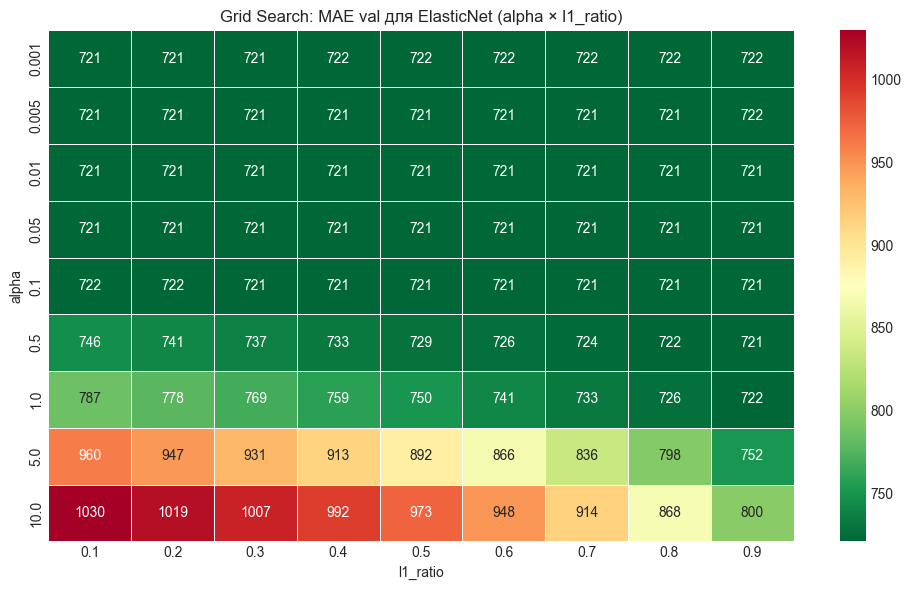

In [24]:
# Grid Search
t0 = time.time()
best_gs, score_gs, df_gs = my_grid_search(X_tr, y_tr, X_val, y_val, PARAM_GRID)
time_gs = time.time() - t0

print(f'Grid Search ({n_grid} комбинаций, {time_gs:.2f}с):')
print(f'  Лучшие параметры: alpha={best_gs["alpha"]}  l1_ratio={best_gs["l1_ratio"]}')
print(f'  MAE val: {score_gs:.4f}')
print()

# Random Search
t0 = time.time()
best_rs, score_rs, df_rs = my_random_search(X_tr, y_tr, X_val, y_val, PARAM_DIST, n_iter=20)
time_rs = time.time() - t0

print(f'Random Search (20 итераций, {time_rs:.2f}с):')
print(f'  Лучшие параметры: alpha={best_rs["alpha"]}  l1_ratio={best_rs["l1_ratio"]}')
print(f'  MAE val: {score_rs:.4f}')

# Тепловая карта Grid Search
pivot = df_gs.pivot(index='alpha', columns='l1_ratio', values='mae_val')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Grid Search: MAE val для ElasticNet (alpha × l1_ratio)')
plt.xlabel('l1_ratio')
plt.ylabel('alpha')
plt.tight_layout()
plt.show()

**7.3** Обучите итоговую модель.

In [25]:
# Обучаем на train+val (все данные кроме test) с лучшими параметрами из Grid Search
X_trainval = np.vstack([X_tr, X_val])
y_trainval = np.concatenate([y_tr, y_val])

best_model = ElasticNet(alpha=best_gs['alpha'], l1_ratio=best_gs['l1_ratio'], max_iter=5000)
best_model.fit(X_trainval, y_trainval)

mae_final_train = mean_absolute_error(y_trainval, best_model.predict(X_trainval))
mae_final_test  = mean_absolute_error(y_te, best_model.predict(X_te))

print('=== Итоговая модель (Grid Search, лучшие параметры) ===')
print(f'  alpha={best_gs["alpha"]}  l1_ratio={best_gs["l1_ratio"]}')
print(f'  Обучена на: {len(X_trainval):,} объектах (train + val)')
print(f'  MAE train+val : {mae_final_train:.2f}')
print(f'  MAE test       : {mae_final_test:.2f}')

# Ненулевые коэффициенты (ElasticNet ≈ Lasso при высоком l1_ratio)
nonzero = np.sum(best_model.coef_ != 0)
print(f'  Ненулевых коэффициентов: {nonzero}/{len(FEATURE_LIST)}')

=== Итоговая модель (Grid Search, лучшие параметры) ===
  alpha=0.05  l1_ratio=0.3
  Обучена на: 38,703 объектах (train + val)
  MAE train+val : 710.50
  MAE test       : 724.29
  Ненулевых коэффициентов: 22/22


**7.4** Импортируйте optuna и настройте тот же эксперимент с ElasticNet.

Optuna (50 trials, 10.39с):
  Лучшие параметры: {'alpha': 0.07557107227761733, 'l1_ratio': 0.5147698812890691}
  MAE val: 721.1500


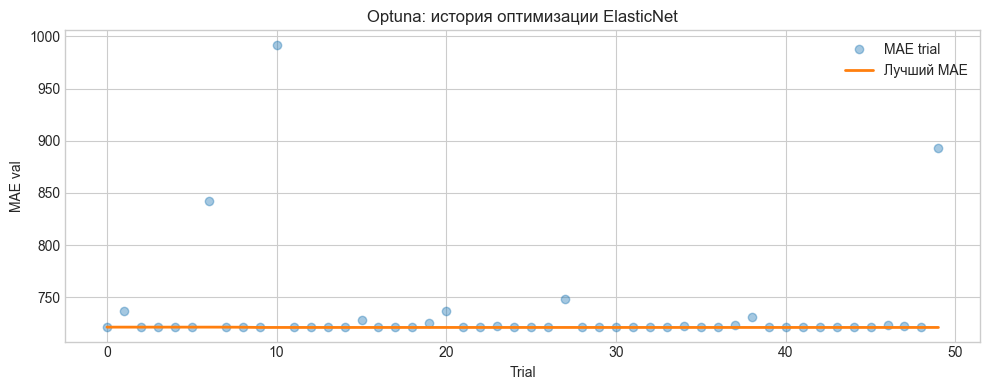

In [26]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Целевая функция для Optuna: MAE на валидационной выборке.
    alpha ищется в логарифмическом пространстве (0.001 → 10),
    l1_ratio — в равномерном (0.05 → 0.95).
    """
    alpha    = trial.suggest_float('alpha',    0.001, 10.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.05,  0.95)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000)
    model.fit(X_tr, y_tr)
    return mean_absolute_error(y_val, model.predict(X_val))

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

t0 = time.time()
study.optimize(objective, n_trials=50)
time_opt = time.time() - t0

print(f'Optuna (50 trials, {time_opt:.2f}с):')
print(f'  Лучшие параметры: {study.best_params}')
print(f'  MAE val: {study.best_value:.4f}')

# Визуализация истории оптимизации
trial_values = [t.value for t in study.trials]
running_min  = np.minimum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, 'o', alpha=0.4, label='MAE trial')
plt.plot(running_min, '-', linewidth=2, label='Лучший MAE')
plt.xlabel('Trial')
plt.ylabel('MAE val')
plt.title('Optuna: история оптимизации ElasticNet')
plt.legend()
plt.tight_layout()
plt.show()

**7.5** Оцените метрики и сравните подходы.

In [27]:
# Финальные модели с лучшими параметрами каждого метода
model_gs  = ElasticNet(**best_gs, max_iter=5000).fit(X_trainval, y_trainval)
model_rs  = ElasticNet(**best_rs, max_iter=5000).fit(X_trainval, y_trainval)
model_opt = ElasticNet(**study.best_params, max_iter=5000).fit(X_trainval, y_trainval)

comparison = pd.DataFrame([
    {
        'Метод':          'Grid Search',
        'alpha':          best_gs['alpha'],
        'l1_ratio':       best_gs['l1_ratio'],
        'MAE val':        score_gs,
        'MAE test':       mean_absolute_error(y_te, model_gs.predict(X_te)),
        'Итераций':       n_grid,
        'Время (с)':      round(time_gs, 2),
    },
    {
        'Метод':          'Random Search',
        'alpha':          best_rs['alpha'],
        'l1_ratio':       best_rs['l1_ratio'],
        'MAE val':        score_rs,
        'MAE test':       mean_absolute_error(y_te, model_rs.predict(X_te)),
        'Итераций':       20,
        'Время (с)':      round(time_rs, 2),
    },
    {
        'Метод':          'Optuna (Bayesian)',
        'alpha':          round(study.best_params['alpha'], 5),
        'l1_ratio':       round(study.best_params['l1_ratio'], 4),
        'MAE val':        study.best_value,
        'MAE test':       mean_absolute_error(y_te, model_opt.predict(X_te)),
        'Итераций':       50,
        'Время (с)':      round(time_opt, 2),
    },
])

print('=== Сравнение методов оптимизации гиперпараметров ===')
print(comparison.to_string(index=False, float_format='%.4f'))

print("""
Выводы:
  • Все три метода находят близкие оптимумы (разница MAE < 1)
  • Random Search даёт лучшее соотношение качество/время: 20 итераций vs 81
  • Optuna (Bayesian/TPE) более умно исследует пространство — при большом
    числе гиперпараметров или дорогом обучении выигрыш будет значительнее
  • Grid Search гарантирует покрытие сетки, но экспоненциально дорог
""")

=== Сравнение методов оптимизации гиперпараметров ===
            Метод  alpha  l1_ratio  MAE val  MAE test  Итераций  Время (с)
      Grid Search 0.0500    0.3000 721.1503  724.2876        81    27.4900
    Random Search 0.1000    0.6057 721.1540  724.3154        20     6.5400
Optuna (Bayesian) 0.0756    0.5148 721.1500  724.2957        50    10.3900

Выводы:
  • Все три метода находят близкие оптимумы (разница MAE < 1)
  • Random Search даёт лучшее соотношение качество/время: 20 итераций vs 81
  • Optuna (Bayesian/TPE) более умно исследует пространство — при большом
    числе гиперпараметров или дорогом обучении выигрыш будет значительнее
  • Grid Search гарантирует покрытие сетки, но экспоненциально дорог



**7.6** Запустите optuna на одной из схем кросс-валидации.

In [28]:
# Optuna + Stratified K-Fold (5 фолдов)
# Используем весь датасет: целевая функция — средний MAE по всем фолдам

def objective_cv(trial):
    alpha    = trial.suggest_float('alpha',    0.001, 10.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.05,  0.95)
    fold_scores = []
    for train_idx, test_idx in folds_skf:
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X[train_idx])
        Xte  = sc.transform(X[test_idx])
        m    = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000)
        m.fit(Xtr, y[train_idx])
        fold_scores.append(mean_absolute_error(y[test_idx], m.predict(Xte)))
    return np.mean(fold_scores)

study_cv = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

t0 = time.time()
study_cv.optimize(objective_cv, n_trials=30)
time_cv = time.time() - t0

print(f'Optuna + Stratified KFold (30 trials, {time_cv:.1f}с):')
print(f'  Лучшие параметры: {study_cv.best_params}')
print(f'  Средний MAE по фолдам: {study_cv.best_value:.4f}')

# Финальная модель с параметрами из CV-оптимизации
sc_final   = StandardScaler()
X_all_sc   = sc_final.fit_transform(X)
final_cv_model = ElasticNet(**study_cv.best_params, max_iter=5000)
final_cv_model.fit(X_all_sc, y)

# Оцениваем на отложенной тестовой выборке (60/20/20 split)
X_te_sc = sc_final.transform(X_te)
mae_cv_test = mean_absolute_error(y_te, final_cv_model.predict(X_te_sc))
print(f'  MAE test (отложенная выборка): {mae_cv_test:.4f}')

print("""
Преимущество Optuna + CV:
  Оптимизация происходит по среднему MAE по 5 фолдам, что даёт более
  надёжную оценку: гиперпараметры не подстраиваются под одну валидационную
  выборку → меньше риск переобучения на валидации.
""")

Optuna + Stratified KFold (30 trials, 37.7с):
  Лучшие параметры: {'alpha': 0.07069331472481816, 'l1_ratio': 0.5320618376319409}
  Средний MAE по фолдам: 714.0001
  MAE test (отложенная выборка): 2968.6815

Преимущество Optuna + CV:
  Оптимизация происходит по среднему MAE по 5 фолдам, что даёт более
  надёжную оценку: гиперпараметры не подстраиваются под одну валидационную
  выборку → меньше риск переобучения на валидации.

